In [47]:
import pandas as pd

df = pd.read_excel("/content/hdi_data_final.xlsx")
print(df.head())

                        Region   SHDI  Health_Index  Income_Index  \
0  Andaman and Nicobar Islands  0.804         0.857         0.756   
1               Andhra Pradesh  0.723         0.807         0.709   
2            Arunachal Pradesh  0.770         0.864         0.714   
3                        Assam  0.699         0.811         0.609   
4                        Bihar  0.650         0.766         0.588   

   Education_Index  tot population  2022  tele-density_internet_tab  \
0            0.802                   402                     111.83   
1            0.662                 52972                      69.03   
2            0.738                  1548                      73.62   
3            0.693                 35378                      58.84   
4            0.610                124919                      44.53   

   tele-density_wireless(mobile)_supporting  Broadband_rural  Broadband_urban  \
0                                    122.19             0.19             0.19

In [48]:
def normalize(col):
    return (col - col.min()) / (col.max() - col.min())

df["internet_norm"] = normalize(df["tele-density_internet_tab"])
df["wireless_norm"] = normalize(df["tele-density_wireless(mobile)_supporting"])

print(df[["internet_norm", "wireless_norm"]].head())


   internet_norm  wireless_norm
0       0.556889       0.558584
1       0.202731       0.216194
2       0.240712       0.234874
3       0.118411       0.154884
4       0.000000       0.000000


In [49]:
print(df["normalised_BB_teledensity "].head())

0    0.129414
1    0.092019
2    0.102746
3    0.081622
4    0.061712
Name: normalised_BB_teledensity , dtype: float64


In [50]:
df["Digital_Index"] = (
    df["internet_norm"] +
    df["wireless_norm"] +
    df["normalised_BB_teledensity "]
) / 3

print(df[["Region", "Digital_Index"]].head())

                        Region  Digital_Index
0  Andaman and Nicobar Islands       0.414962
1               Andhra Pradesh       0.170315
2            Arunachal Pradesh       0.192777
3                        Assam       0.118306
4                        Bihar       0.020571


In [51]:
df["Digital_Index_norm"] = normalize(df["Digital_Index"])

print(df[["Region", "Digital_Index_norm"]].head())

                        Region  Digital_Index_norm
0  Andaman and Nicobar Islands            0.547128
1               Andhra Pradesh            0.207735
2            Arunachal Pradesh            0.238897
3                        Assam            0.135585
4                        Bihar            0.000000


In [52]:
df["AI_HDI"] = (
    df["Health_Index"] *
    df["Education_Index"] *
    df["Income_Index"] *
    df["Digital_Index_norm"]
) ** (1/4)

print(df[["Region", "AI_HDI"]].head())

                        Region    AI_HDI
0  Andaman and Nicobar Islands  0.730199
1               Andhra Pradesh  0.529629
2            Arunachal Pradesh  0.574275
3                        Assam  0.464136
4                        Bihar  0.000000


In [53]:
df["Difference"] = df["AI_HDI"] - df["SHDI"]

print(df[["Region", "SHDI", "AI_HDI", "Difference"]].head())

                        Region   SHDI    AI_HDI  Difference
0  Andaman and Nicobar Islands  0.804  0.730199   -0.073801
1               Andhra Pradesh  0.723  0.529629   -0.193371
2            Arunachal Pradesh  0.770  0.574275   -0.195725
3                        Assam  0.699  0.464136   -0.234864
4                        Bihar  0.650  0.000000   -0.650000


In [54]:
df["Rank_AI_HDI"] = df["AI_HDI"].rank(ascending=False)

print(df[["Region", "AI_HDI", "Rank_AI_HDI"]].sort_values("Rank_AI_HDI").head(10))

                         Region    AI_HDI  Rank_AI_HDI
24                    New Delhi  0.875015          1.0
9                           Goa  0.856880          2.0
5                   Chandigarth  0.788640          3.0
16                       Kerala  0.752965          4.0
0   Andaman and Nicobar Islands  0.730199          5.0
11                      Haryana  0.728544          6.0
12             Himachal Pradesh  0.712583          7.0
21                    Meghalaya  0.708079          8.0
22                      Mizoram  0.698476          9.0
17                  Lakshadweep  0.695305         10.0


In [55]:
from xgboost import XGBRegressor

X = df[[
    "Health_Index",
    "Education_Index",
    "Income_Index",
    "Digital_Index_norm"
]]

y = df["AI_HDI"]

model = XGBRegressor()
model.fit(X, y)

df["Predicted_AI_HDI"] = model.predict(X)

print(df[["Region", "AI_HDI", "Predicted_AI_HDI"]].head())

                        Region    AI_HDI  Predicted_AI_HDI
0  Andaman and Nicobar Islands  0.730199          0.729751
1               Andhra Pradesh  0.529629          0.529396
2            Arunachal Pradesh  0.574275          0.574334
3                        Assam  0.464136          0.464107
4                        Bihar  0.000000          0.001302


In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [57]:
from sklearn.metrics import r2_score

print(r2_score(y_test, y_pred))

0.00040798414393461435


split among 36 test and train

In [58]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor

model = XGBRegressor()

scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print(scores)
print(scores.mean())

[ 0.65499153  0.88985786  0.90139326 -0.51656555 -1.69899073]
0.04613727250370445


In [59]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [60]:
from sklearn.linear_model import Ridge

model = Ridge()

In [61]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print(scores)
print("Mean R2:", scores.mean())

[0.35864336 0.83350447 0.76335782 0.92847822 0.82436028]
Mean R2: 0.7416688297207278


In [62]:
model.fit(X, y)

Ridge()

In [63]:
df["Predicted_AI_HDI"] = model.predict(X)

print(df[["Region", "AI_HDI", "Predicted_AI_HDI"]].head())

                        Region    AI_HDI  Predicted_AI_HDI
0  Andaman and Nicobar Islands  0.730199          0.677562
1               Andhra Pradesh  0.529629          0.526615
2            Arunachal Pradesh  0.574275          0.552647
3                        Assam  0.464136          0.493768
4                        Bihar  0.000000          0.427889


In [64]:
import pandas as pd

importance = pd.Series(model.coef_, index=X.columns)
print(importance)

Health_Index          0.051718
Education_Index       0.148571
Income_Index          0.117124
Digital_Index_norm    0.359630
dtype: float64


In [65]:
import pandas as pd
sample = {
    "Health_Index": 0.8,
    "Education_Index": 0.7,
    "Income_Index": 0.6,
    "Digital_Index_norm": 0.5
             }
sample_df = pd.DataFrame([sample])

model.predict(sample_df)

array([0.62423961])

In [66]:
baseline = model.predict(pd.DataFrame([X.mean()]))
new = model.predict(sample_df)

print("Baseline:", baseline)
print("After change:", new)
print("Impact:", new - baseline)

Baseline: [0.5849824]
After change: [0.62423961]
Impact: [0.0392572]


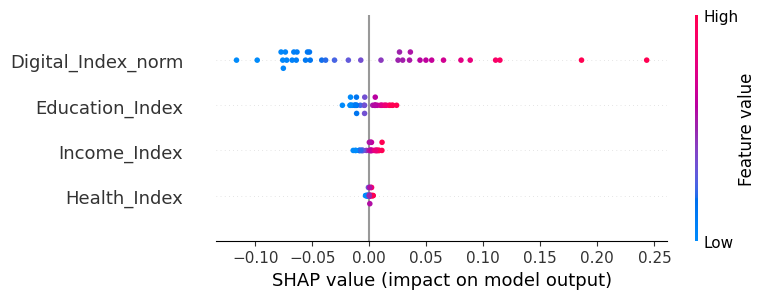

In [67]:
import shap

explainer = shap.Explainer(model, X)
shap_values = explainer(X)

shap.summary_plot(shap_values, X)

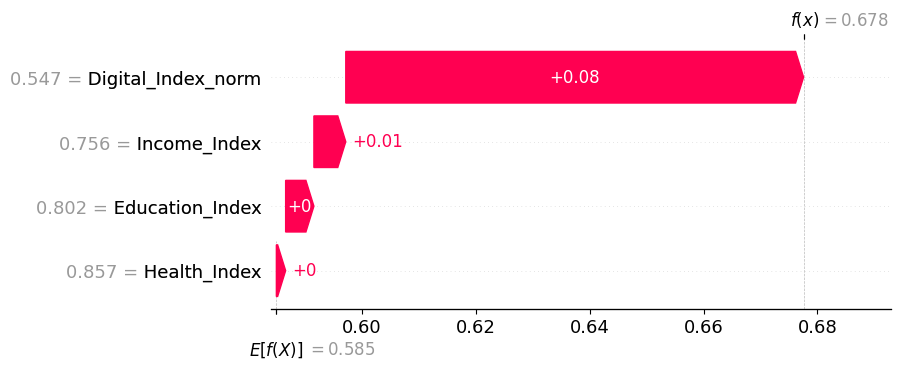

In [68]:
shap.plots.waterfall(shap_values[0])

In [69]:
print("\nLearned Weights (Model Coefficients):")
print(importance.sort_values(ascending=False))


Learned Weights (Model Coefficients):
Digital_Index_norm    0.359630
Education_Index       0.148571
Income_Index          0.117124
Health_Index          0.051718
dtype: float64


In [70]:
df.to_excel("final_output.xlsx", index=False)

In [71]:
import os
print(os.listdir())

['.config', 'final_output.xlsx', 'hdi_data_final.xlsx', 'sample_data']


In [72]:
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# ===== LOAD YOUR DATA =====
df = pd.read_excel("final_output.xlsx")

# ===== FEATURES & TARGET =====
X = df[["Health_Index","Education_Index","Income_Index","Digital_Index_norm"]]
y = df["AI_HDI"]

# ===== TRAIN MODEL =====
model = Ridge()
model.fit(X, y)

# ===== MODEL ACCURACY =====
y_pred = model.predict(X)
accuracy = r2_score(y, y_pred)

print(f"\nModel Accuracy (R²): {round(accuracy,3)}")

# ===== USER INPUT =====
print("\nEnter values between 0 and 1")

health = float(input("Health Index: "))
education = float(input("Education Index: "))
income = float(input("Income Index: "))
digital = float(input("Digital Index: "))

# ===== TRADITIONAL HDI =====
hdi = (health * education * income) ** (1/3)

# ===== AI-HDI (FORMULA) =====
ai_hdi = (health * education * income * digital) ** (1/4)

# ===== ML PREDICTION =====
input_df = pd.DataFrame([[health, education, income, digital]],
                        columns=X.columns)

predicted = model.predict(input_df)[0]

# ===== IMPACT =====
impact = ai_hdi - hdi

# ===== DRIVER ANALYSIS (COEFFICIENTS) =====
importance = pd.Series(model.coef_, index=X.columns)
top_driver = importance.abs().idxmax()

# ===== OUTPUT =====
print("\n===== RESULTS =====")
print(f"Traditional HDI: {round(hdi,3)}")
print(f"AI-Augmented HDI (Formula): {round(ai_hdi,3)}")
print(f"Predicted AI-HDI (ML): {round(predicted,3)}")

print(f"\nImpact of Digital Addition: {round(impact,3)}")

print(f"\nTop Driving Factor: {top_driver}")
print("\nFeature Importance:")
print(importance.sort_values(ascending=False))


Model Accuracy (R²): 0.734

Enter values between 0 and 1
Health Index: 0.8
Education Index: 0.7
Income Index: 0.7
Digital Index: 0.9

===== RESULTS =====
Traditional HDI: 0.732
AI-Augmented HDI (Formula): 0.771
Predicted AI-HDI (ML): 0.78

Impact of Digital Addition: 0.039

Top Driving Factor: Digital_Index_norm

Feature Importance:
Digital_Index_norm    0.359630
Education_Index       0.148571
Income_Index          0.117124
Health_Index          0.051718
dtype: float64


In [73]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']

In [74]:
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [75]:
from sklearn.metrics import mean_squared_error
import numpy as np
y = df["AI_HDI"]   # your target column
X = df[["Health_Index","Education_Index","Income_Index","Digital_Index_norm"]]
rmse = np.sqrt(mean_squared_error(y, model.predict(X)))
print("RMSE:", rmse)


RMSE: 0.08201020059069832


In [76]:
residuals = y - model.predict(X)

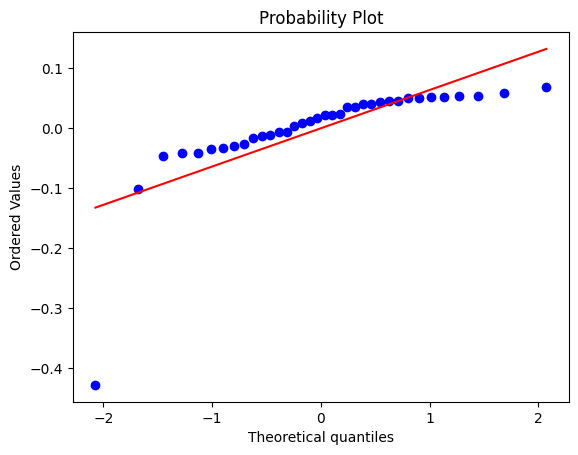

In [77]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(residuals, dist="norm", plot=plt)
plt.show()

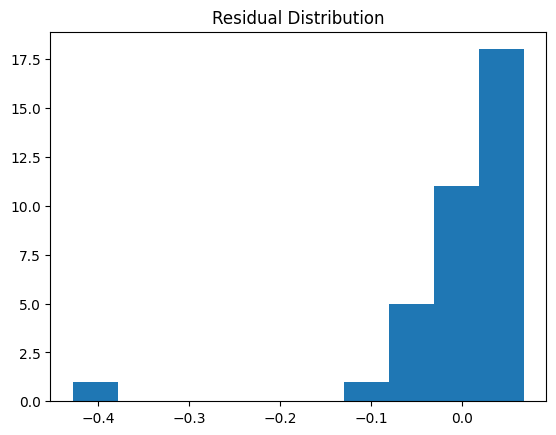

In [78]:
plt.hist(residuals)
plt.title("Residual Distribution")
plt.show()

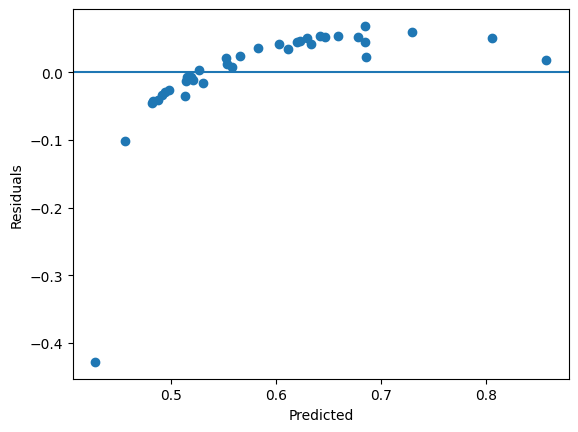

In [79]:
y_pred = model.predict(X)

plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

In [80]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

              feature         VIF
0        Health_Index  474.045196
1     Education_Index  239.741805
2        Income_Index  552.916945
3  Digital_Index_norm    7.288237


In [81]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(scores)
print("Mean R2:", scores.mean())

[0.35864336 0.83350447 0.76335782 0.92847822 0.82436028]
Mean R2: 0.7416688297207279


In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model.fit(X_train, y_train)

print("Train R2:", model.score(X_train, y_train))
print("Test R2:", model.score(X_test, y_test))

Train R2: 0.8070346165332409
Test R2: 0.1852540628555549
